In [1]:
import pandas as pd
import sweetviz as sv
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, recall_score
import matplotlib.pyplot as plt

# Changin Model to RandomForest
from sklearn.ensemble import RandomForestClassifier
# Changin Model to XGBoost
from xgboost import XGBClassifier

import joblib

In [2]:
df = pd.read_csv("heart.csv")

                                             |          | [  0%]   00:00 -> (? left)


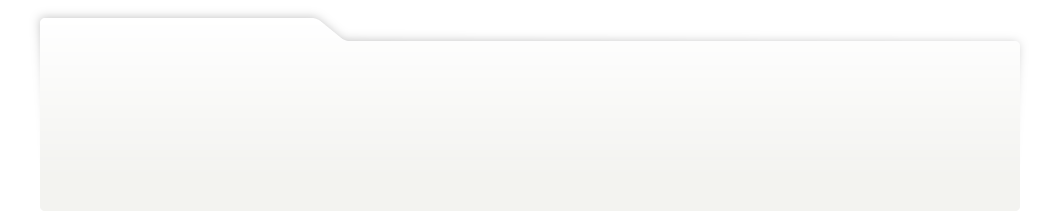
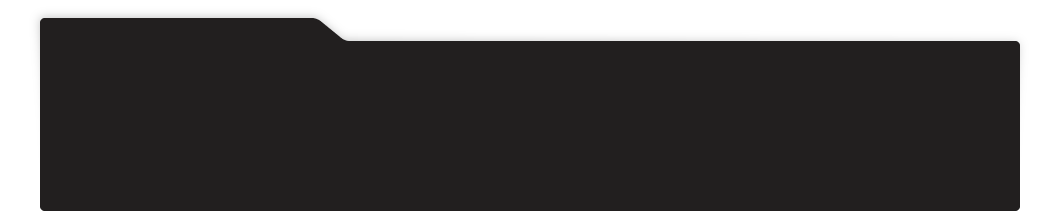
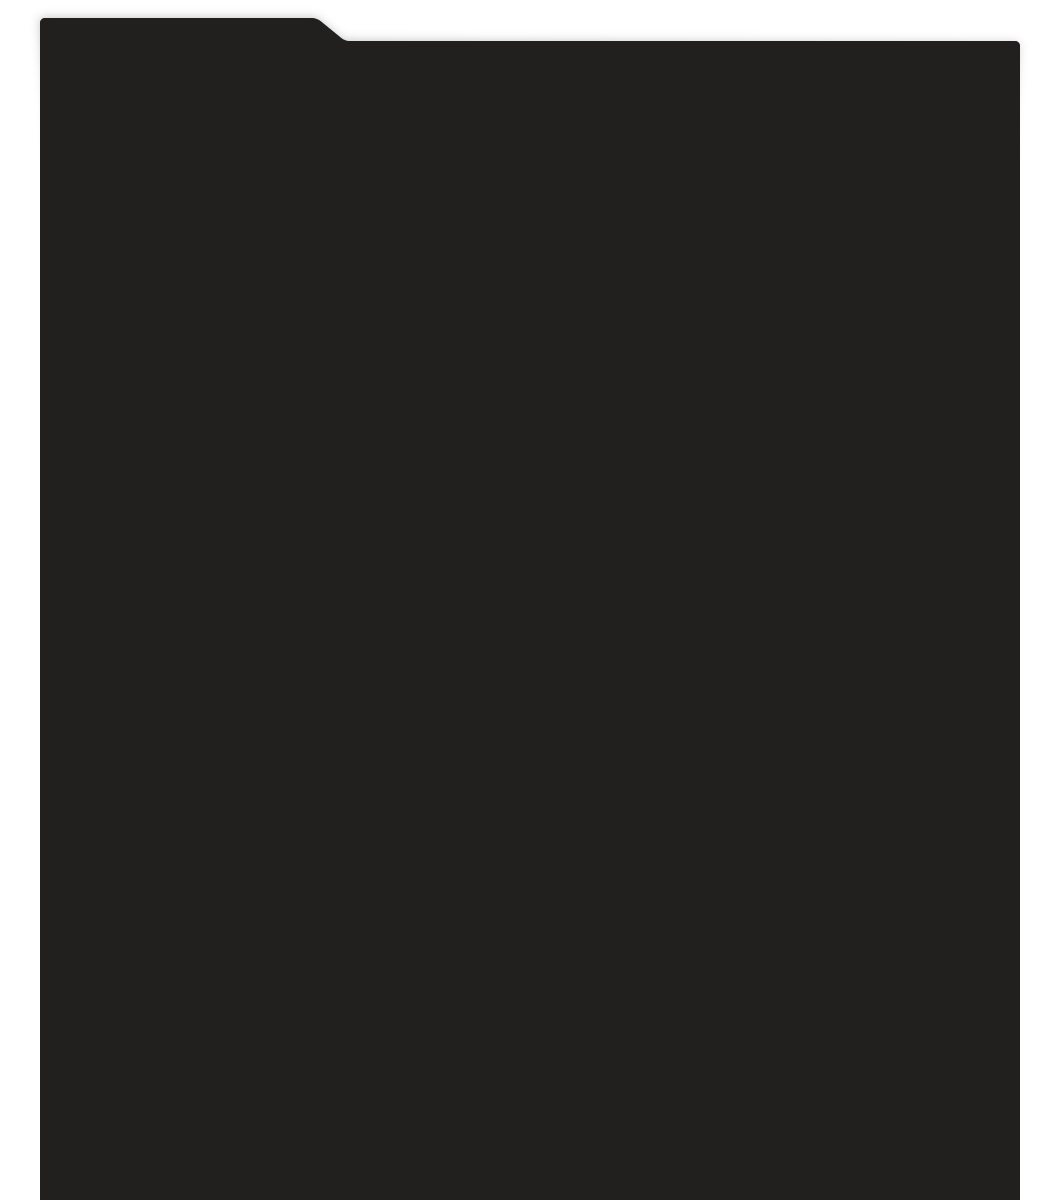
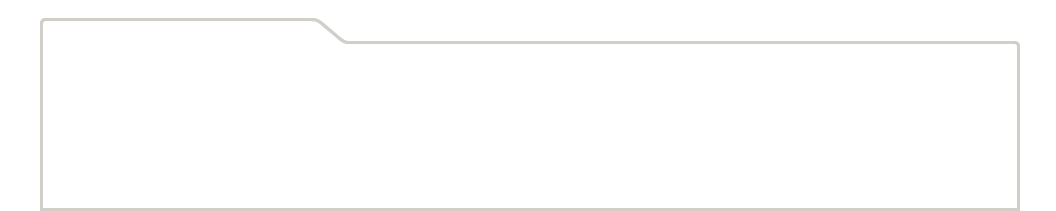
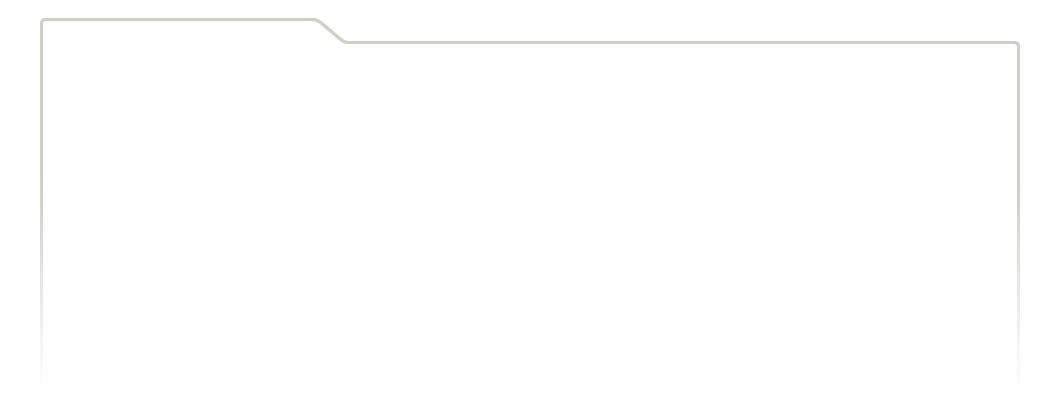
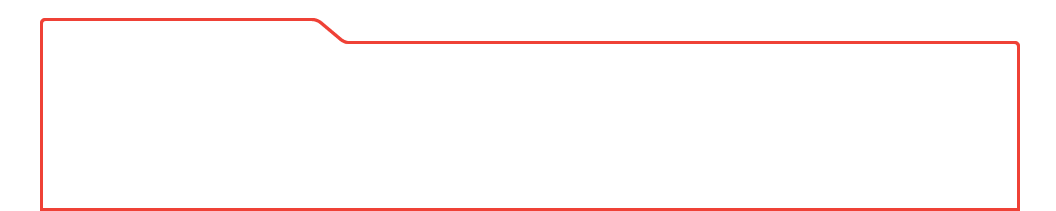
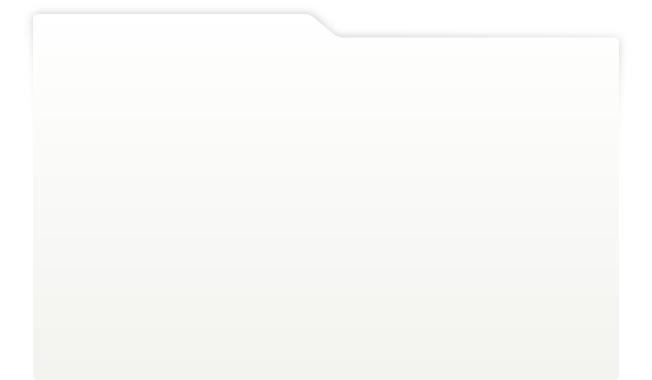
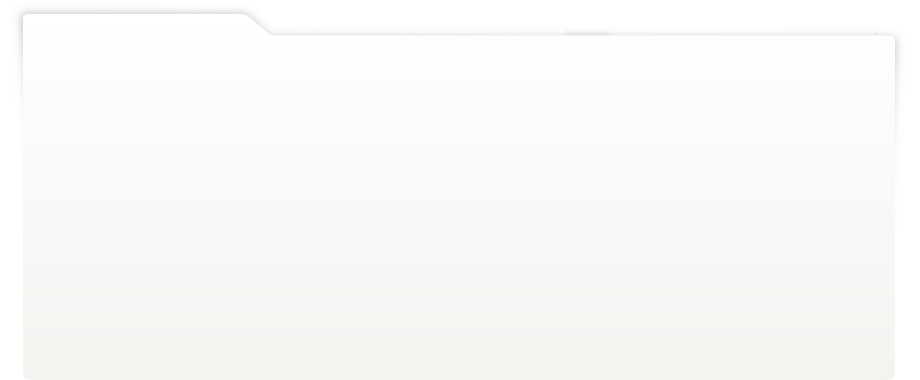
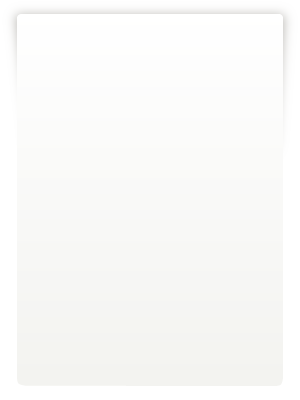
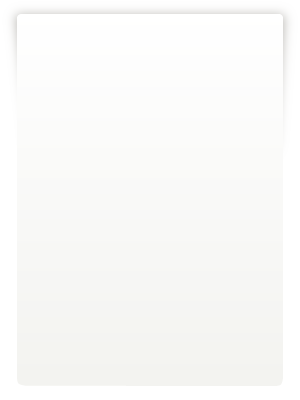
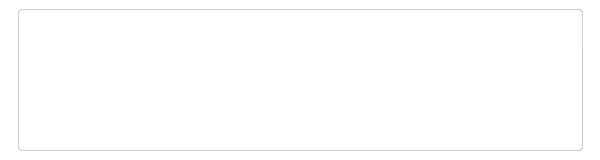
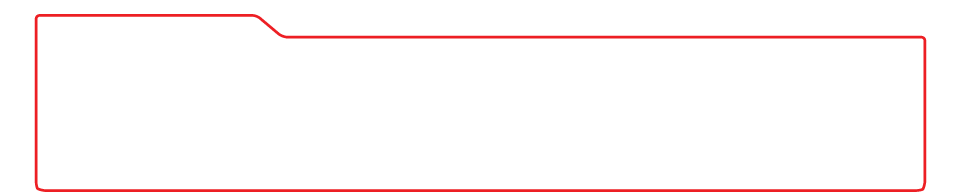
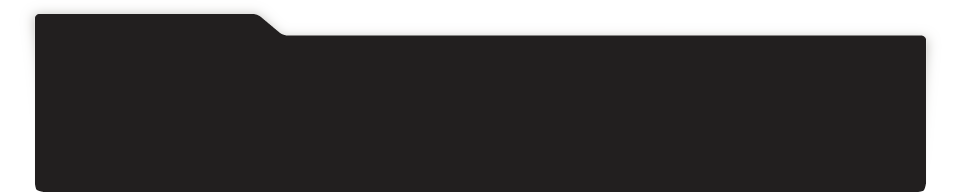
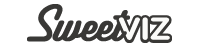
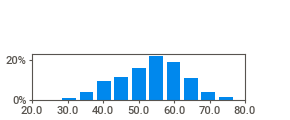
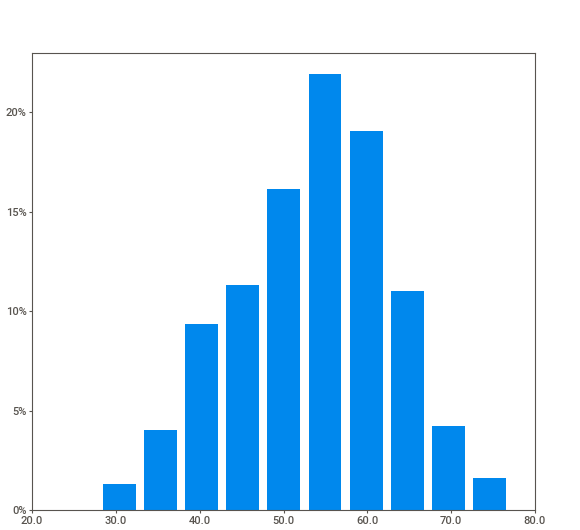
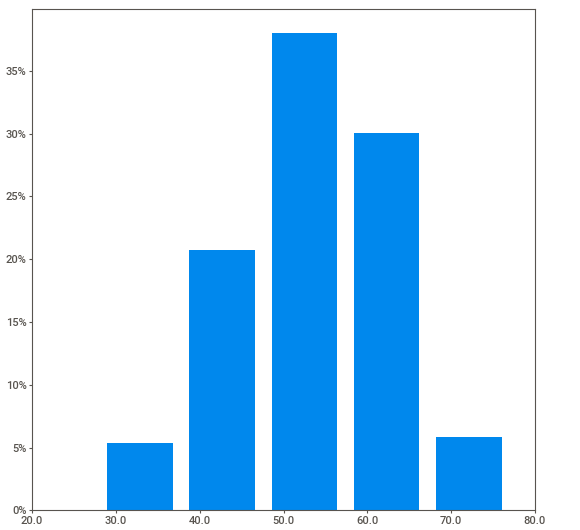
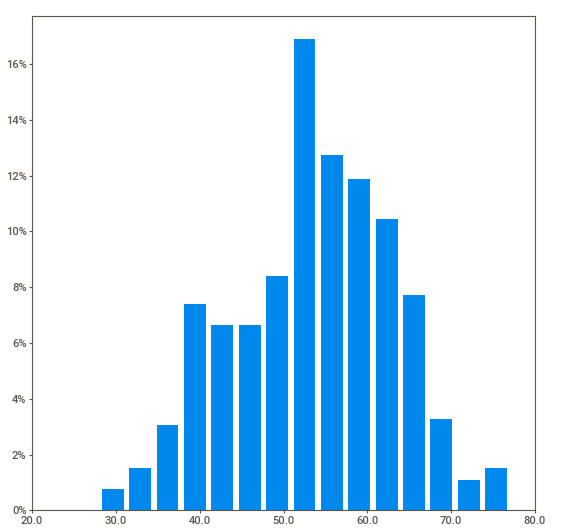
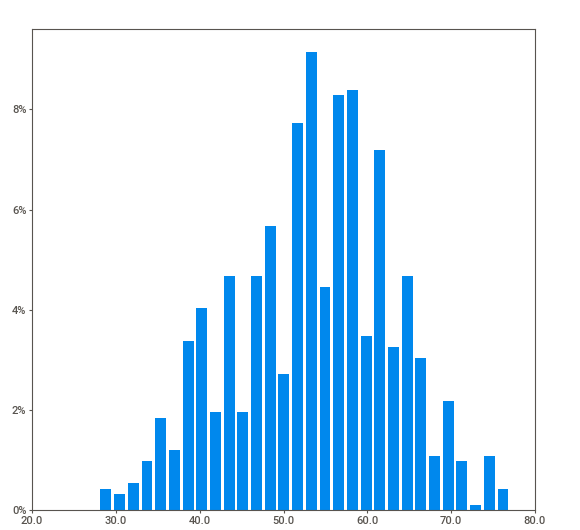
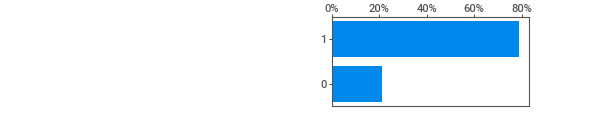
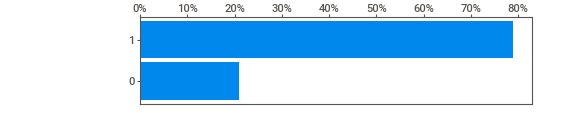
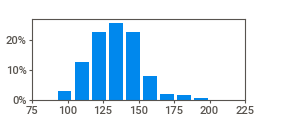
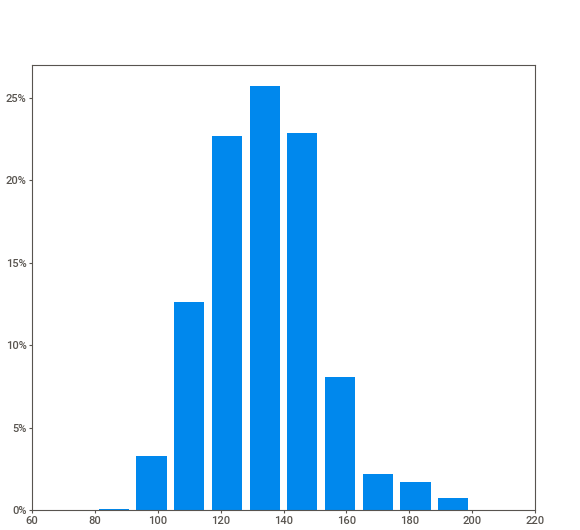
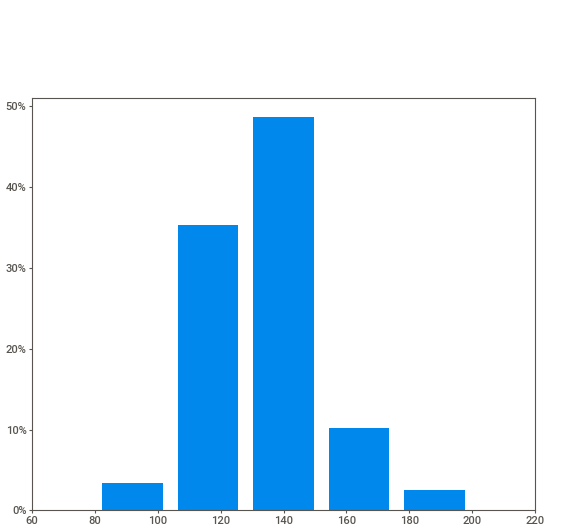
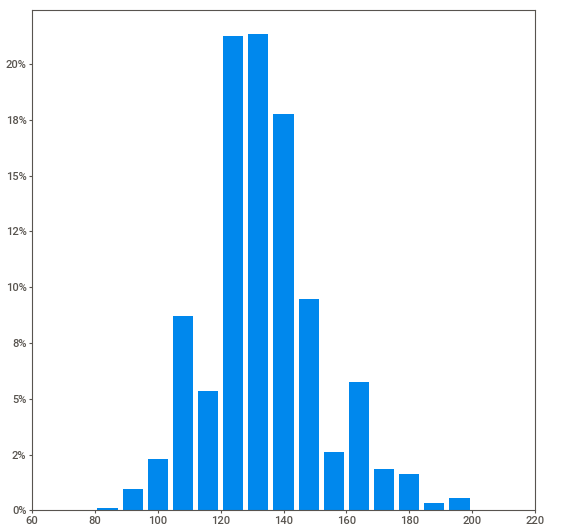
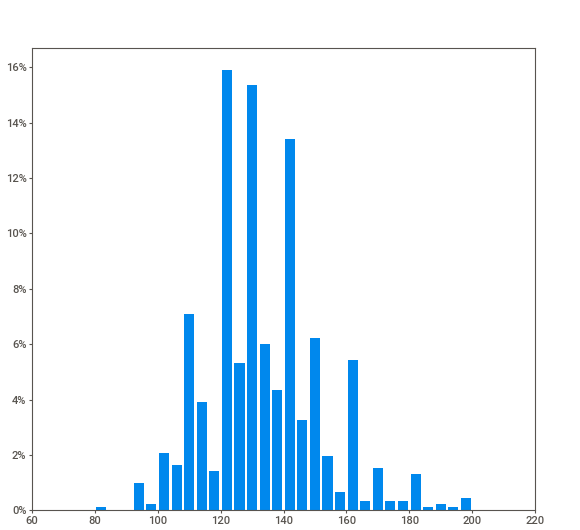
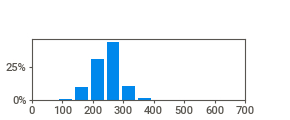
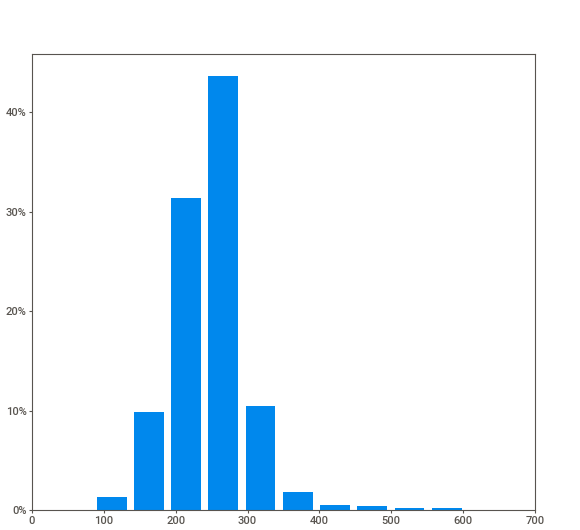
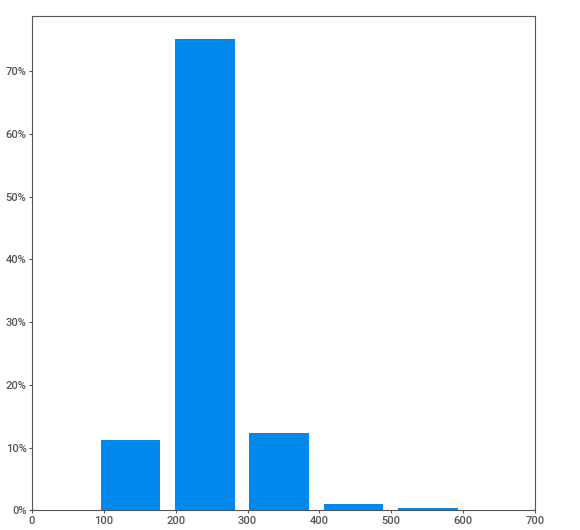
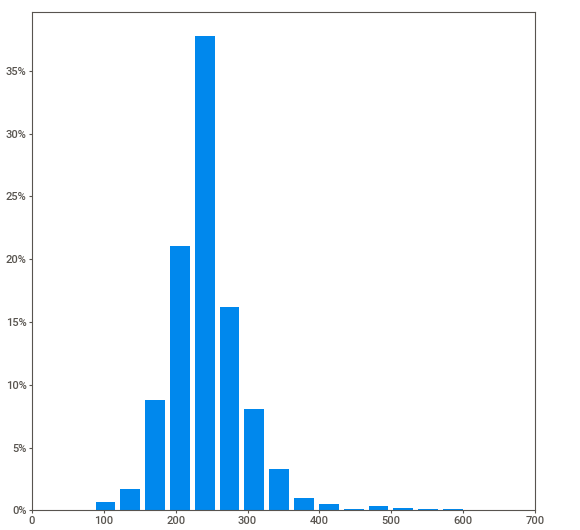
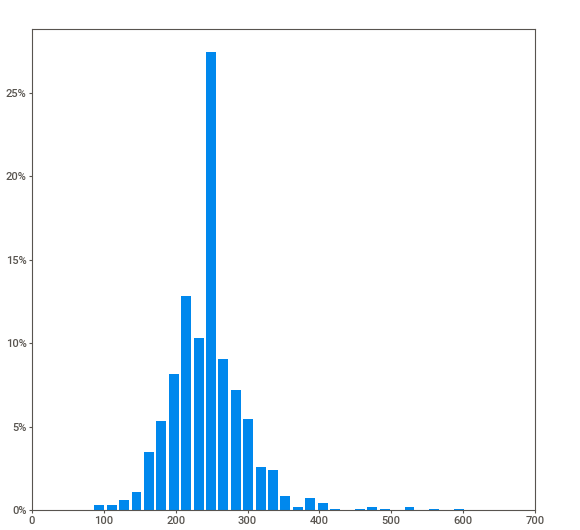
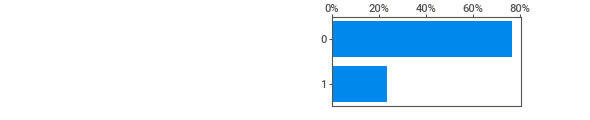
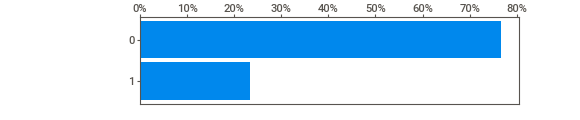
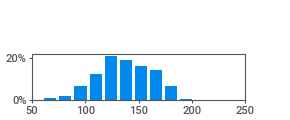
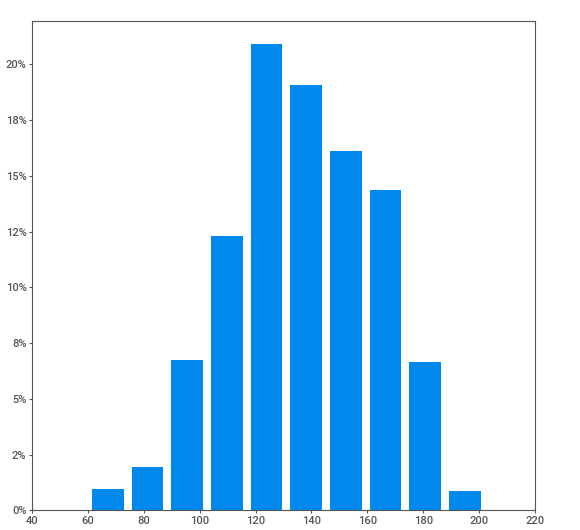
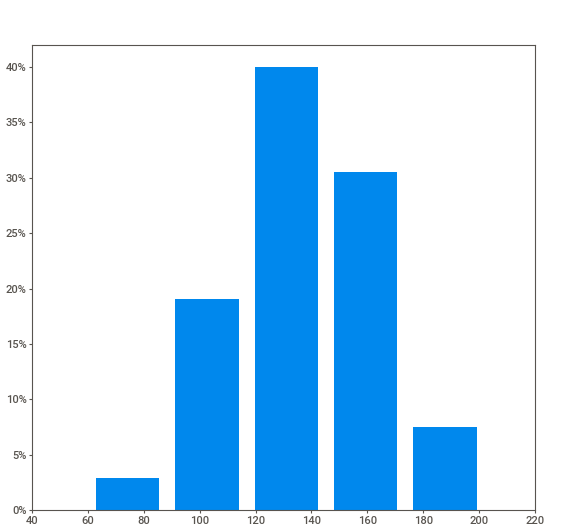
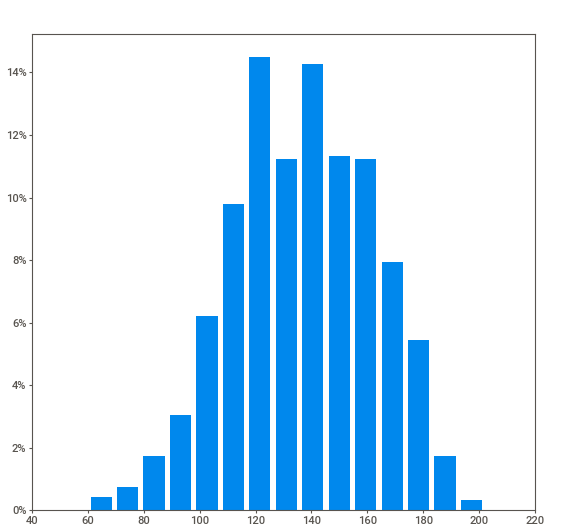
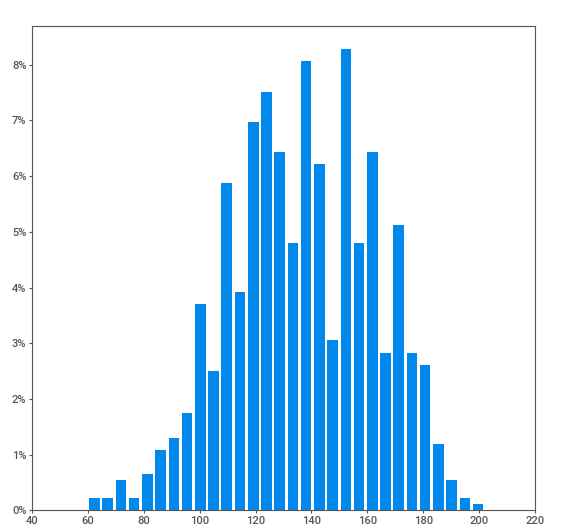
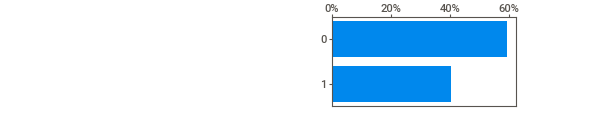
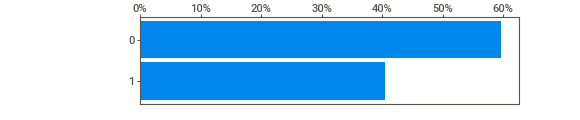
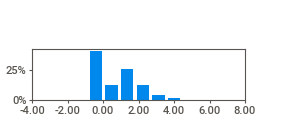
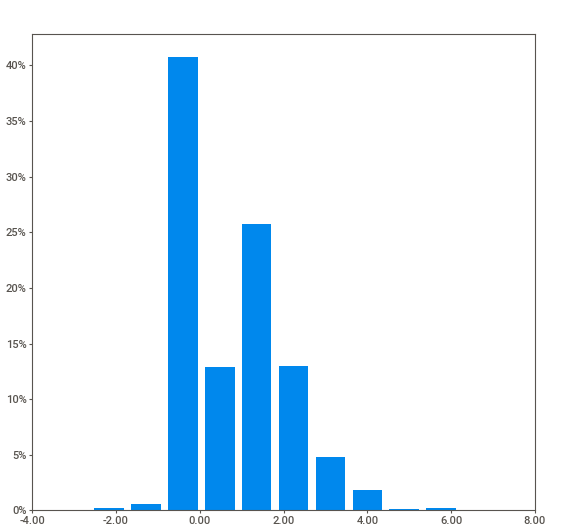
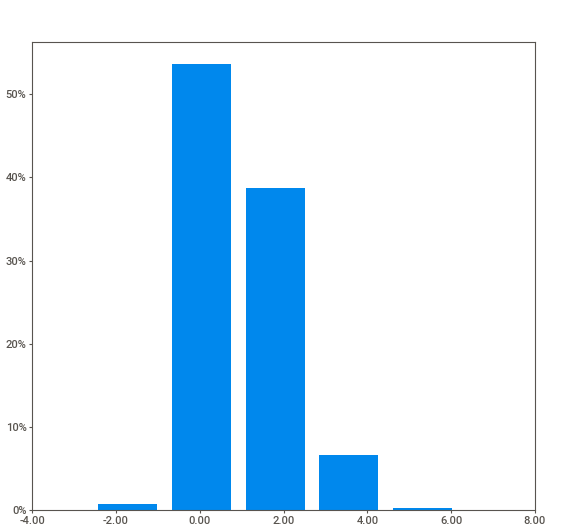
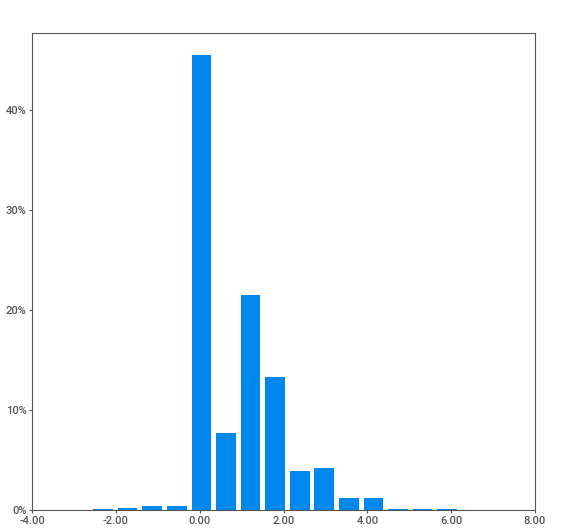
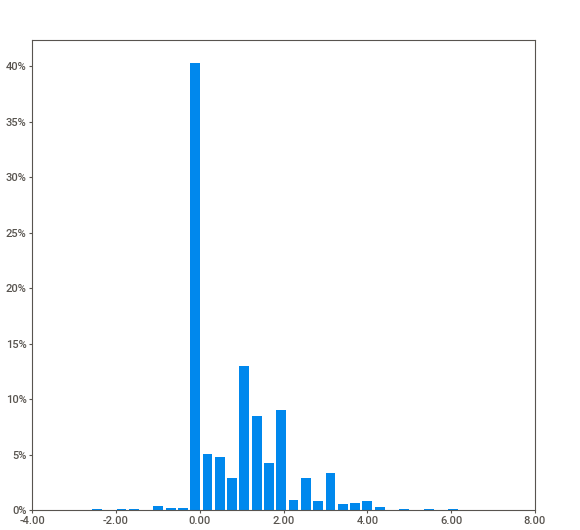
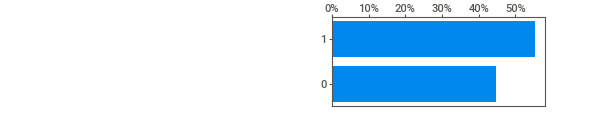
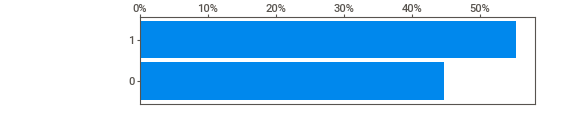
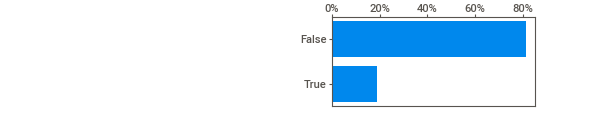
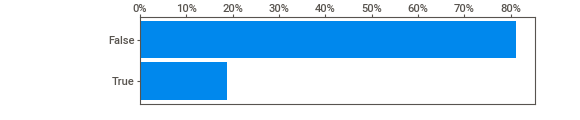
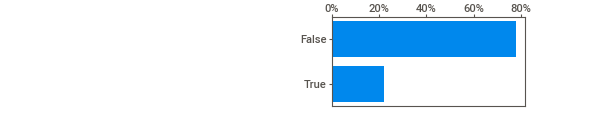
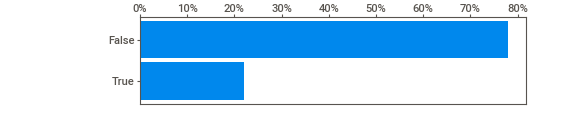
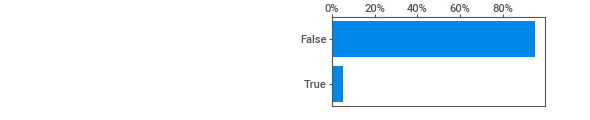
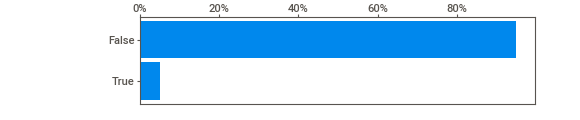
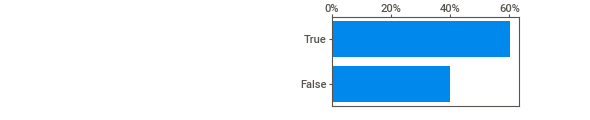
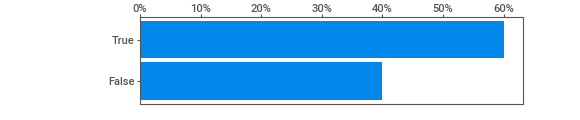
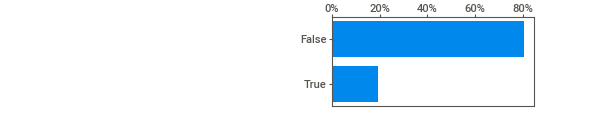
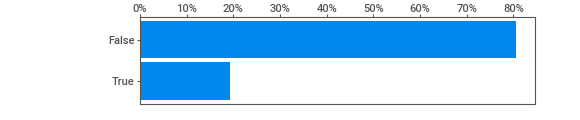
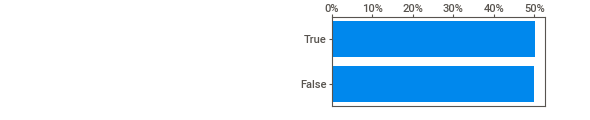
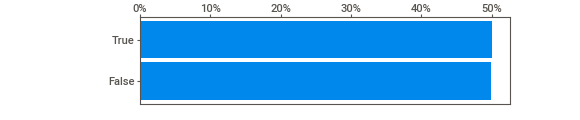
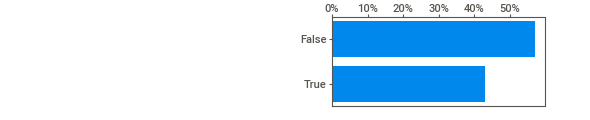
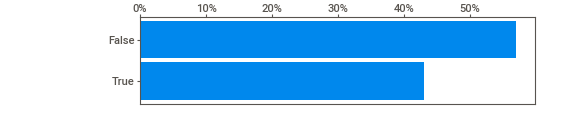
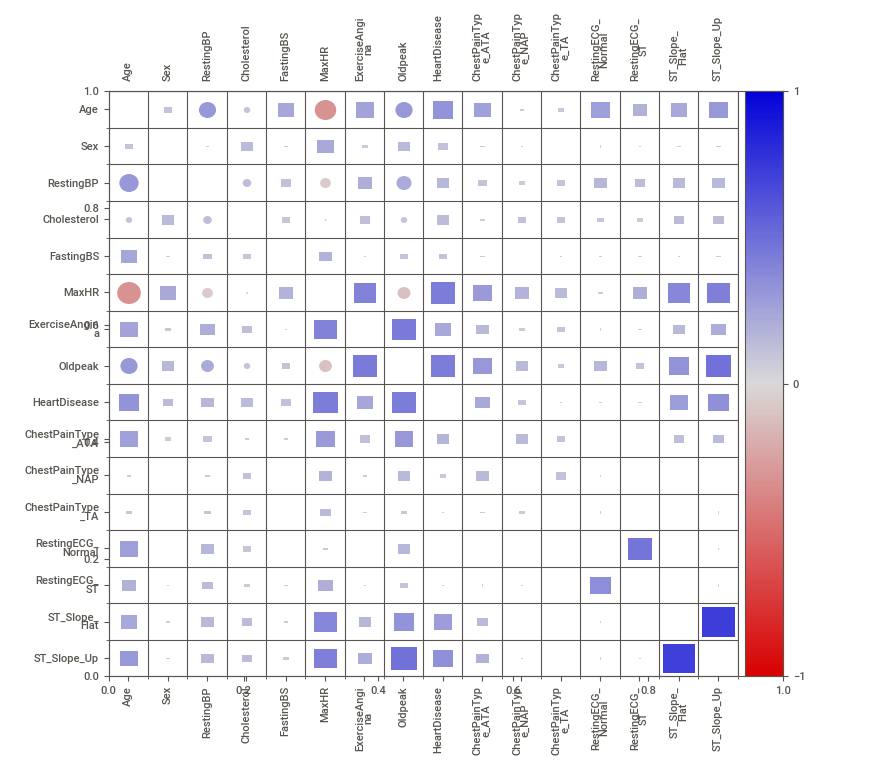
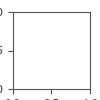

In [3]:
# Preparing Data
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].mean())
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].mean())
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

report = sv.analyze(df)
report.show_notebook()

In [4]:
# Scaling features
scaler = StandardScaler()
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [10]:
# Seprating data into train and test groups
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Base Model
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)
print(f"Baseline Accuracy (Validation): {baseline_accuracy: 0.2%}")

Baseline Accuracy (Validation):  58.15%


In [7]:
# Logstic Regression (LR)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_model_preds = lr_model.predict(X_test)
lr_model_accuracy = accuracy_score(y_test, lr_model_preds)
lr_model_recall = recall_score(y_test, lr_model_preds) 

# Logstic Regression Model (threshold to 0.3)
lr_probabilities = lr_model.predict_proba(X_test)
lr_prob_disease = lr_probabilities[:, 1]
lr_new_threshold = 0.3
lr_custom_preds = (lr_prob_disease >= lr_new_threshold).astype(int)
lr_custom_threshold_accuracy = accuracy_score(y_test, lr_custom_preds)
lr_custom_threshold_recall = recall_score(y_test, lr_custom_preds) 

# RandomForest 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)

# RandomForest (threshold to 0.3)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_custom_preds = (rf_probs >= 0.3).astype(int)
rf_custom_accuracy = accuracy_score(y_test, rf_custom_preds)
rf_custom_recall = recall_score(y_test, rf_custom_preds) 

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds) 

print(f"{"Model":<30} | {"Accuracy":<10} | {"Recall":<10}")
print("-" * 58)
print(f"{"LR Default (0.5)":<30} | {lr_model_accuracy:<10.2%} | {lr_model_recall:<10.2%}")
print(f"{"LR Custom (0.3)":<30} | {lr_custom_threshold_accuracy:<10.2%} | {lr_custom_threshold_recall:<10.2%}")
print(f"{"RF Default (0.5)":<30} | {rf_accuracy:<10.2%} | {rf_recall:<10.2%}")
print(f"{"RF Custom (0.3)":<30} | {rf_custom_accuracy:<10.2%} | {rf_custom_recall:<10.2%}")
print(f"{"XGBoost Default (0.5)":<30} | {xgb_accuracy:<10.2%} | {xgb_recall:<10.2%}")

Model                          | Accuracy   | Recall    
----------------------------------------------------------
LR Default (0.5)               | 86.41%     | 85.05%    
LR Custom (0.3)                | 87.50%     | 91.59%    
RF Default (0.5)               | 87.50%     | 88.79%    
RF Custom (0.3)                | 84.78%     | 91.59%    
XGBoost Default (0.5)          | 82.61%     | 82.24%    


<div dir='rtl'>
Accuracy (دقت کل): می‌گوید از کل آدم‌هایی که بررسی کردیم (چه سالم، چه بیمار)، چند نفر را درست حدس زدیم.<br>
Recall (حساسیت): فقط روی بیماران تمرکز دارد و می‌گوید از بین کسانی که واقعاً بیمار بودند، چند نفر را توانستیم پیدا کنیم و از قلم نیفتادند.<br>
اگر بهای اشتباه کردن در هر دو حالت برابر است (مثلاً تشخیص عکس سگ از گربه)، Accuracy معیار خوبی است.
اما اگر جا انداختن یک مورد خاص خطر جانی یا مالی سنگین دارد (مثل جا انداختن بیمار قلبی)، Accuracy کاملاً گول‌زننده است و فقط باید به Recall نگاه کنید.
</div>

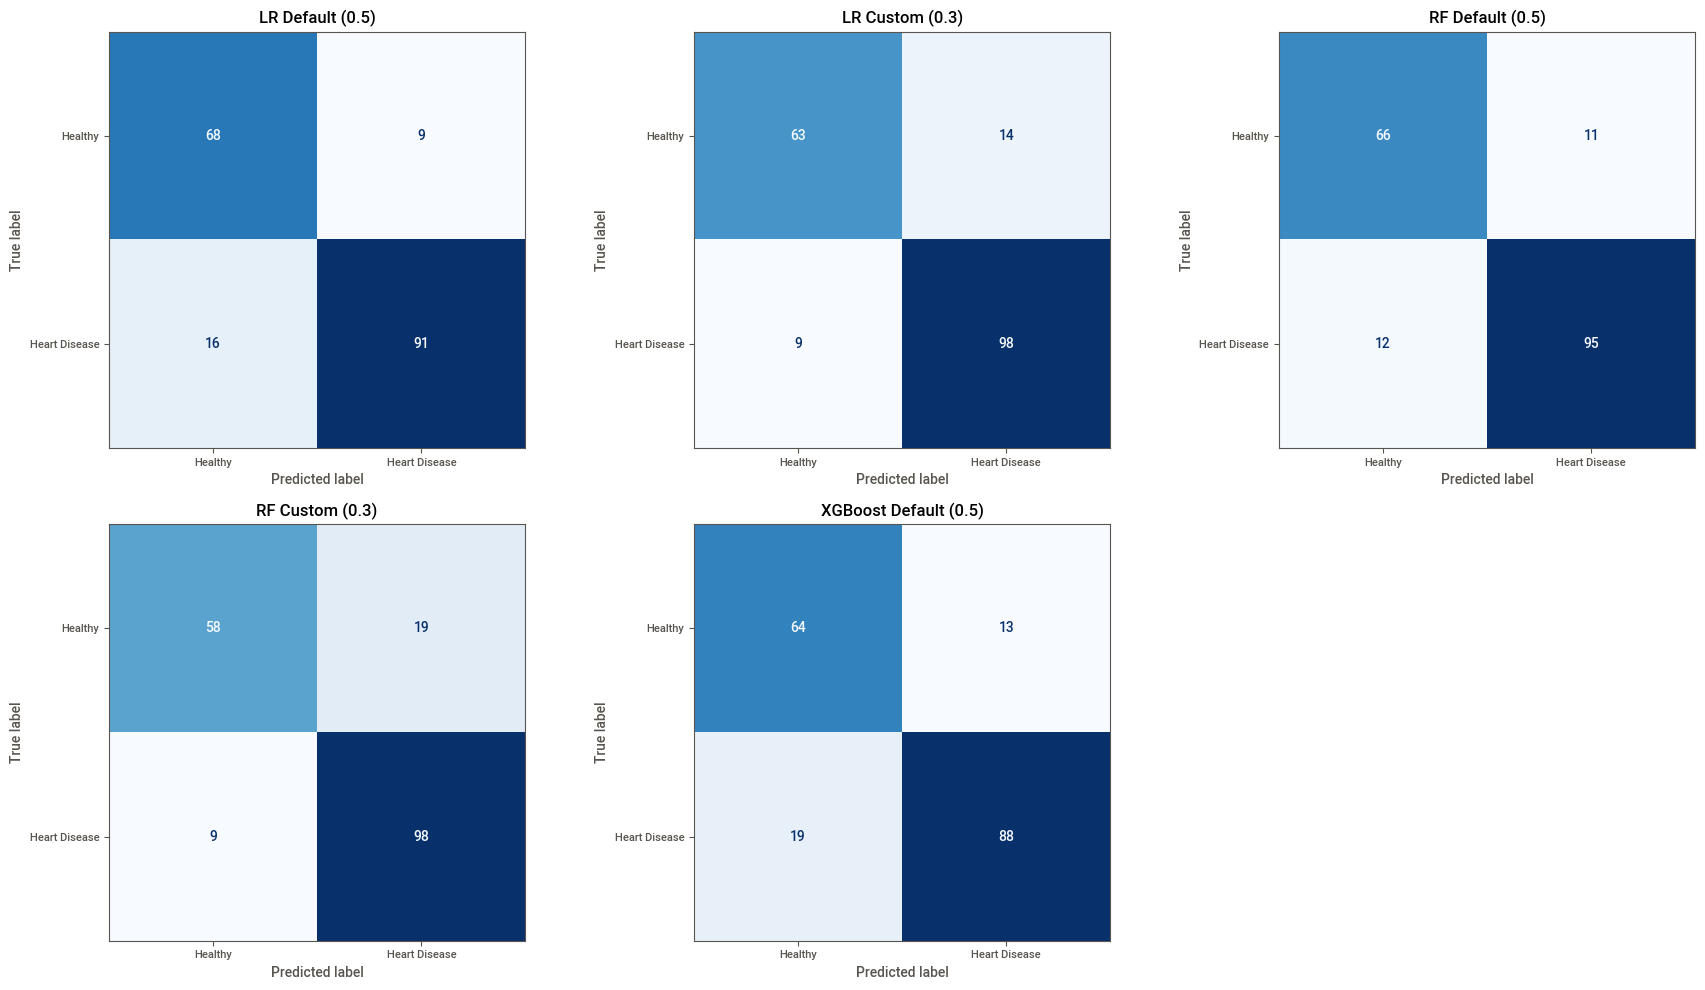

In [8]:
# Ploting Data
all_predictions = [
    ("LR Default (0.5)", lr_model_preds),
    ("LR Custom (0.3)", lr_custom_preds),
    ("RF Default (0.5)", rf_preds),
    ("RF Custom (0.3)", rf_custom_preds),
    ("XGBoost Default (0.5)", xgb_preds)
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, (title, preds) in enumerate(all_predictions):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Heart Disease'])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, colorbar=False)
    axes[i].set_title(title, fontsize=12, fontweight='bold')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

In [12]:
joblib.dump(lr_model, 'medical_lr_model.pkl')
joblib.dump(scaler, 'medical_scaler.pkl')
print("Model saved successfully!")

Model saved successfully!
